# Train with Multi-Objective Reward

This notebook shows how to train agents using the **Multi-Objective** reward function.

This is your original implementation that combines multiple objectives:
- Return maximization
- Volatility control
- Diversification (concentration penalty)
- Turnover minimization (transaction cost proxy)

## Formula
`Reward = Return - λ₁*Volatility - λ₂*Concentration - λ₃*Turnover`

## Setup

In [1]:
from train import train, train_all_algos, train_both_agents
from utils import print_results, compare_results, save_results
from config import get_config

print("✓ Imports ready!")

✓ Imports ready!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Train Technical Agent (Aggressive Profile)

Technical agent uses aggressive parameters:
- `return_scale`: 8.0 (high emphasis on returns)
- `volatility_penalty`: 0.050 (low volatility penalty)
- `concentration_penalty`: 0.250 (allows concentration)
- `turnover_penalty`: 0.005 (allows frequent trading)

In [ ]:

config_tech = get_config('multi_objective', 'technical')

# These are optimal values (already fixed in refactored config.py)
config_tech['return_scale'] = 8.0
config_tech['volatility_penalty'] = 0.050
config_tech['max_concentration'] = 0.50
config_tech['concentration_penalty'] = 0.250
config_tech['turnover_penalty'] = 0.01

config_tech['gamma'] = 0.90                    # ✅ Perfect for weekly
config_tech['softmax_temperature'] = 1.5       # ✅ Balanced decisions
config_tech['patience'] = 10                   # ✅ Proper convergence
config_tech['learning_rate'] = 3e-4            # ✅ Standard
config_tech['total_steps'] = 300_000           # ✅ Sufficient
config_tech['transaction_cost'] = 0.0025        # ✅ Realistic (10 bps)



In [3]:
# Train with PPO - uses technical agent parameters from config
result_tech = train(
    agent_type='technical',
    algorithm='PPO',
    reward_type='multi_objective',
    verbose=True
)

print(f"\nTechnical Agent Parameters:")


print(f"  Return Scale:          {config_tech['return_scale']}")
print(f"  Volatility Penalty:    {config_tech['volatility_penalty']}")
print(f"  Concentration Penalty: {config_tech['concentration_penalty']}")
print(f"  Turnover Penalty:      {config_tech['turnover_penalty']}")


Training: TECHNICAL - MULTI_OBJECTIVE - PPO
Gamma: 0.9
Softmax temp: 1.0
Patience: 15
Environment: 201 dates, 7 assets, 20 features
Transaction cost: 25.0 bps
Using cpu device

Training for 300,000 steps...
-----------------------------
| time/              |      |
|    fps             | 1579 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1489         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0135300085 |
|    clip_fraction        | 0.115        |
|    clip_range           | 0.2          |
|    entropy_loss         | -9.93        |
|    explained_variance   | -0.0835      |
|    learning_rate        | 0.0003       |
|    loss              

## 2. Train Sentiment Agent (Conservative Profile)

Sentiment agent uses conservative parameters:
- `return_scale`: 3.0 (moderate emphasis on returns)
- `volatility_penalty`: 0.2 (high volatility penalty)
- `concentration_penalty`: 1.0 (strong diversification)
- `turnover_penalty`: 0.02 (discourages frequent trading)

In [4]:
# Train with PPO - uses sentiment agent parameters from config
result_sent = train(
    agent_type='sentiment',
    algorithm='PPO',
    reward_type='multi_objective',
    verbose=True
)

print(f"\nSentiment Agent Parameters:")
config_sent = get_config('multi_objective', 'sentiment')
print(f"  Return Scale:          {config_sent['return_scale']}")
print(f"  Volatility Penalty:    {config_sent['volatility_penalty']}")
print(f"  Concentration Penalty: {config_sent['concentration_penalty']}")
print(f"  Turnover Penalty:      {config_sent['turnover_penalty']}")


Training: SENTIMENT - MULTI_OBJECTIVE - PPO
Gamma: 0.9
Softmax temp: 1.0
Patience: 15
Environment: 196 dates, 7 assets, 12 features
Transaction cost: 25.0 bps
Using cpu device

Training for 300,000 steps...
-----------------------------
| time/              |      |
|    fps             | 1569 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1518        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012637251 |
|    clip_fraction        | 0.121       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.93       |
|    explained_variance   | -4.38       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0397 

## 3. Compare Technical vs Sentiment


MULTI-OBJECTIVE COMPARISON (PPO)
                   Agent  Train Sharpe  Val Sharpe  Test Sharpe
  Technical (Aggressive)         0.968       2.258        1.171
Sentiment (Conservative)         1.151       2.350        1.040


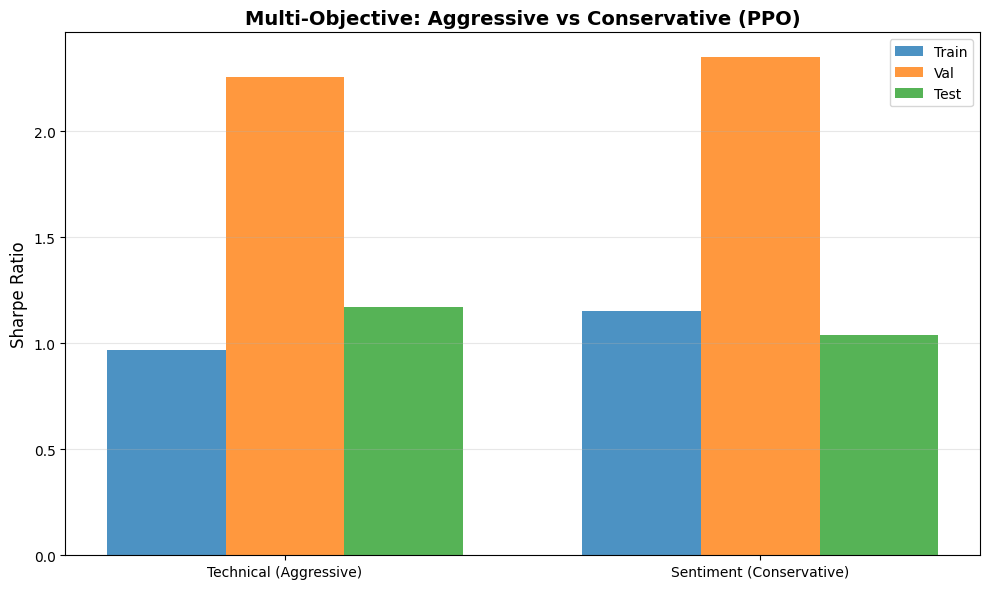

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison
comparison_data = {
    'Agent': ['Technical (Aggressive)', 'Sentiment (Conservative)'],
    'Train Sharpe': [result_tech['train_sharpe'], result_sent['train_sharpe']],
    'Val Sharpe': [result_tech['val_sharpe'], result_sent['val_sharpe']],
    'Test Sharpe': [result_tech['test_sharpe'], result_sent['test_sharpe']]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("MULTI-OBJECTIVE COMPARISON (PPO)")
print("="*60)
print(df_comparison.to_string(index=False))
print("="*60)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_comparison))
width = 0.25

ax.bar([i - width for i in x], df_comparison['Train Sharpe'], width, label='Train', alpha=0.8)
ax.bar(x, df_comparison['Val Sharpe'], width, label='Val', alpha=0.8)
ax.bar([i + width for i in x], df_comparison['Test Sharpe'], width, label='Test', alpha=0.8)

ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Multi-Objective: Aggressive vs Conservative (PPO)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Agent'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Try All Algorithms - Technical Agent

In [ ]:
# Technical agent - all algorithms
print("\n" + "="*70)
print("Training TECHNICAL agent with all algorithms")
print("="*70)

tech_results = train_all_algos(
    agent_type='technical',
    reward_type='multi_objective',
    verbose=True
)


Training TECHNICAL agent with all algorithms

Training TECHNICAL with ALL algorithms
Reward: MULTI_OBJECTIVE

PPO: Test Sharpe = 1.009


## 5. Try All Algorithms - Sentiment Agent

In [ ]:
# Sentiment agent - all algorithms
print("\n" + "="*70)
print("Training SENTIMENT agent with all algorithms")
print("="*70)

sent_results = train_all_algos(
    agent_type='sentiment',
    reward_type='multi_objective',
    verbose=True
)

## 6. Compare Results

In [ ]:
# Combine all results
all_results = tech_results + sent_results

# Show comparison
df = compare_results(all_results)

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

best_tech = max(tech_results, key=lambda x: x['test_sharpe'])
best_sent = max(sent_results, key=lambda x: x['test_sharpe'])

print(f"\nBest Technical: {best_tech['algorithm']} - Test Sharpe = {best_tech['test_sharpe']:.3f}")
print(f"Best Sentiment: {best_sent['algorithm']} - Test Sharpe = {best_sent['test_sharpe']:.3f}")

## 7. Customize Penalties

Create a custom profile with different penalty weights.

In [ ]:
# Get base config
config_custom = get_config('multi_objective', 'technical')

# Create a balanced profile (between aggressive and conservative)
config_custom['return_scale'] = 5.0
config_custom['volatility_penalty'] = 0.1
config_custom['concentration_penalty'] = 0.5
config_custom['turnover_penalty'] = 0.01

print("Custom Balanced Profile:")
print(f"  Return Scale:          {config_custom['return_scale']}")
print(f"  Volatility Penalty:    {config_custom['volatility_penalty']}")
print(f"  Concentration Penalty: {config_custom['concentration_penalty']}")
print(f"  Turnover Penalty:      {config_custom['turnover_penalty']}")

# Train with custom config
result_custom = train(
    agent_type='technical',
    algorithm='PPO',
    reward_type='multi_objective',
    config=config_custom,
    verbose=True
)

## 9. Save Results

In [ ]:
# Save all results
results_dict = {
    'approach': 'multi_objective',
    'technical_results': tech_results,
    'sentiment_results': sent_results,
    'best_technical': best_tech,
    'best_sentiment': best_sent,
}

save_results(results_dict, 'results/multi_objective_results.json')

## 📊 Understanding Multi-Objective Reward

The Multi-Objective reward combines multiple objectives with explicit penalties.

### Formula (from rewards.py):
```python
# Objective 1: Return (maximize)
reward_return = port_return * return_scale

# Penalty 1: Volatility (penalize high volatility)
penalty_volatility = -lambda_vol * abs(port_return - mean_return)

# Penalty 2: Concentration (penalize if max weight > 30%)
penalty_concentration = -lambda_conc * max(0, max_weight - 0.3)

# Penalty 3: Turnover (penalize large weight changes)
penalty_turnover = -lambda_turn * sum(abs(weights - prev_weights))

# Combined reward
reward = reward_return + penalty_volatility + penalty_concentration + penalty_turnover
```

### Technical Agent (Aggressive):
- **return_scale**: 8.0 → High emphasis on returns
- **volatility_penalty**: 0.050 → Low penalty, allows volatility
- **concentration_penalty**: 0.250 → Low penalty, allows concentration
- **turnover_penalty**: 0.005 → Low penalty, allows frequent trading

### Sentiment Agent (Conservative):
- **return_scale**: 3.0 → Moderate emphasis on returns
- **volatility_penalty**: 0.2 → High penalty, avoids volatility
- **concentration_penalty**: 1.0 → High penalty, promotes diversification
- **turnover_penalty**: 0.02 → High penalty, discourages frequent trading

### When to Use:
- ✅ When you want explicit control over risk characteristics
- ✅ When you need diversification
- ✅ When transaction costs matter
- ✅ When you want different profiles for different agents
- ❌ More hyperparameters to tune than simple Sharpe

## 🎯 Next Steps

1. Experiment with different penalty weights
2. Create custom profiles (e.g., ultra-conservative, ultra-aggressive)
3. Compare all three reward functions (EMA, Differential, Multi-Objective)
4. Analyze portfolio characteristics (concentration, turnover)
5. Test on different market conditions

## 💡 Parameter Tuning Guide

### Want higher returns with more risk?
- ⬆️ Increase `return_scale`
- ⬇️ Decrease `volatility_penalty`
- ⬇️ Decrease `concentration_penalty`

### Want more stable, diversified portfolios?
- ⬇️ Decrease `return_scale`
- ⬆️ Increase `volatility_penalty`
- ⬆️ Increase `concentration_penalty`

### Want to reduce transaction costs?
- ⬆️ Increase `turnover_penalty`

### Want more active trading?
- ⬇️ Decrease `turnover_penalty`